<left><img width=25% src="img/gw_monogram_2c.png"></left>

# Lecture 11: Neural Networks

### CS6364/CS4364 Machine Learning

__Armin Mehrabina__<br> The George Washington University

# Part 1: An Artifical Neuron

In this lecture, we will learn about a new class of machine learning algorithms inspired by the brain.

We will start by defining a few building blocks for these algorithms, and draw connections to neuroscience.

# Review: Components of A Supervised Machine Learning Problem

At a high level, a supervised machine learning problem has the following structure:

$$ \underbrace{\text{Training Dataset}}_\text{Attributes + Features} + \underbrace{\text{Learning Algorithm}}_\text{Model Class + Objective + Optimizer } \to \text{Predictive Model} $$

# Review: Binary Classification

In supervised learning, we fit a model of the form
$$ f : \mathcal{X} \to \mathcal{Y} $$
that maps inputs $x \in \mathcal{X}$ to targets $y \in \mathcal{Y}$.

In classification, the space of targets $\mathcal{Y}$ is *discrete*. Classification is binary if $\mathcal{Y} = \{0,1\}$

# A Biological Neuron

In order to define an artifical neuron, let's look first at a biological one.

<center>
<img width=60% src="img/bio-neuron.png">
</center>

* Each neuron receives input signals from its dendrites
* If input signals are strong enough, neuron fires output along its axon, which connects to the dendrites of other neurons.

# An Artificial Neuron: Example

We can imitate this machinery using an idealized artifical neuron.
* Dendrite $j$ gets signal $x_j$; modulates multiplicatively to $w_j \cdot x_j$.
* The body of the neuron sums the modulated inputs: $\sum_{j=1}^d w_j \cdot x_j$.
* These go into the activation function that produces an ouput.
<center>
<img width="55%" src="img/aneuron.jpeg">
</center>

# An Artificial Neuron: Notation

More formally, we say that a neuron is a model $f : \mathbb{R}^d \to [0,1]$, with the following components:
* Inputs $x_1,x_2,...,x_d$, denoted by a vector $x$.
* Weight vector $w \in \mathbb{R}^d$ that modulates input $x$ as $w^\top x$.
* An activation function $\sigma: \mathbb{R} \to \mathbb{R}$ that computes the output $\sigma(w^\top x)$ of the neuron based on the sum of modulated features $w^\top x$.

# Perceptron

If we use a step function as the activation function, we obtain the classic Perceptron model:

$$ f(x) = 
\begin{cases}
  1 & \text{if $\theta^\top x>0$}, \\
  0 & \text{otherwise}
\end{cases}
$$

This models a neuron that fires if the inputs are sufficiently large, and doesn't otherwise.

We can visualize the activation function of the Perceptron.

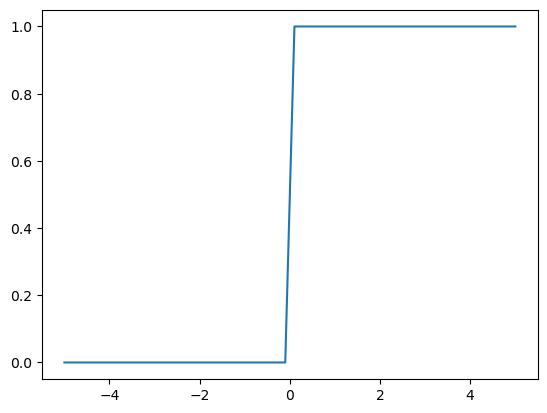

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
z = np.linspace(-5, 5)

step_fn = lambda z: 1 if z > 0 else 0
plt.plot(z, [step_fn(zi) for zi in z])

# Logistic Regression as an Artifical Neuron

Logistic regression is a model of the form
$$ f(x) = \sigma(\theta^\top x) = \frac{1}{1 + \exp(-\theta^\top x)}, $$
that can be interpreted as a neuron that uses the *sigmoid* as the activation function.

The sigmoid activation function encodes the idea of a neuron firing if the inputs exceed a threshold, makes make the activation function "smooth".

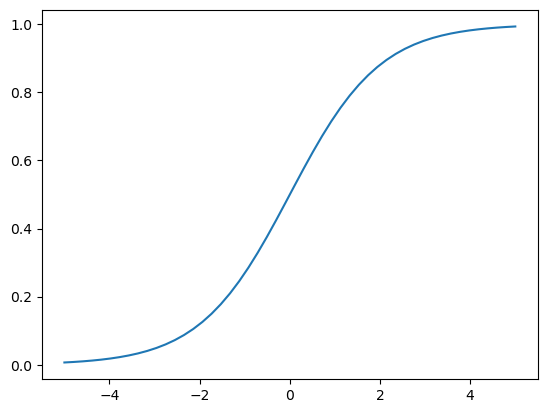

In [2]:
z = np.linspace(-5, 5)
sigma = 1/(1+np.exp(-z))

plt.plot(z, sigma)

# Activation Functions

There are many other activation functions that can be used. In practice, these two work better than the sigmoid:
* Hyperbolic tangent (`tanh`): $\sigma(z) = \tanh(z)$
* Rectified linear unit (`ReLU`): $\sigma(z) = \max(0, z)$
<!-- * Leaky `ReLU`: $$\sigma(z) = \max(\alpha z, z),$$ where $\alpha$ is a small constant such as 0.1. -->

We can easily visualize these.

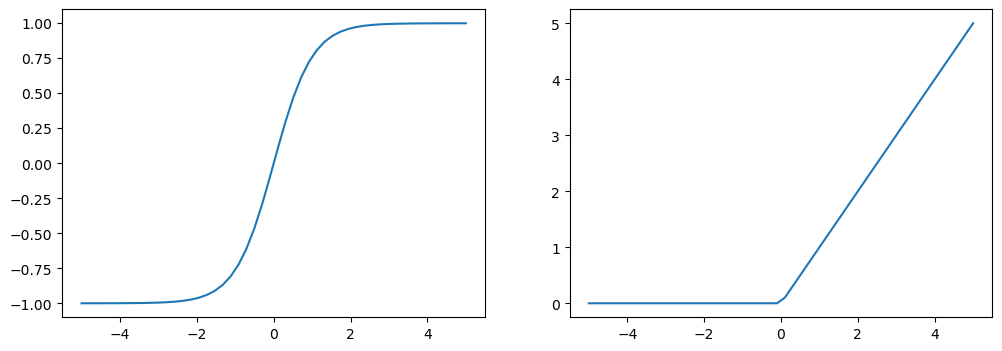

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 4]

plt.subplot(121)
plt.plot(z, np.tanh(z))
plt.subplot(122)
plt.plot(z, np.maximum(z, 0))

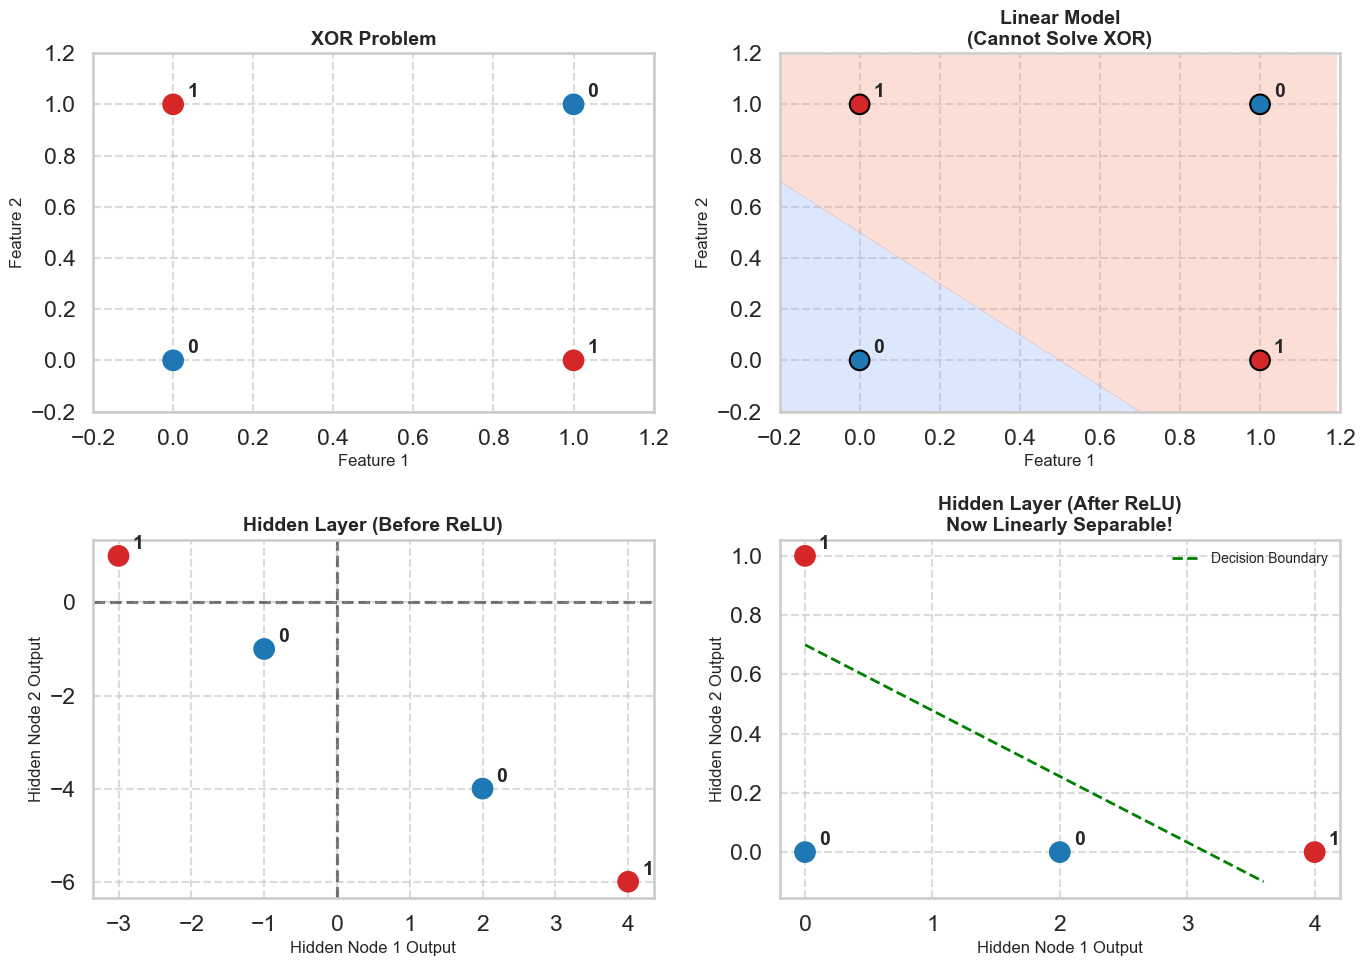

In [30]:
# Visualization: Why Nonlinear Activation Functions Are Necessary

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns

# Set a clean style for presentation
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
sns.set_style("whitegrid")

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Generate XOR problem data - ensure labels match colors consistently
X = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float)
y = torch.tensor([0, 1, 1, 0], dtype=torch.float)  # Class labels

# Plot the XOR problem with consistent colors
blue_color = '#1f77b4'  # Standard matplotlib blue
red_color = '#d62728'   # Standard matplotlib red
colors = np.array([blue_color, red_color, red_color, blue_color])  # Explicitly define colors

axs[0, 0].scatter(X[:, 0], X[:, 1], c=colors, s=200)
axs[0, 0].set_xlim(-0.2, 1.2)
axs[0, 0].set_ylim(-0.2, 1.2)
axs[0, 0].set_xlabel('Feature 1', fontsize=12)
axs[0, 0].set_ylabel('Feature 2', fontsize=12)
axs[0, 0].set_title('XOR Problem', fontsize=14, fontweight='bold')
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# Add class labels
for i, point_class in enumerate(y):
    label = f"{int(point_class)}"
    axs[0, 0].annotate(label, 
                 (X[i, 0], X[i, 1]),
                 xytext=(10, 5),
                 textcoords='offset points',
                 fontsize=14, fontweight='bold')

# Function to visualize decision boundary
def plot_decision_boundary(model, ax, title):
    # Create a mesh grid
    x_min, x_max = -0.2, 1.2
    y_min, y_max = -0.2, 1.2
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Make predictions on the mesh grid
    Z = np.zeros(xx.shape)
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            test_point = torch.tensor([[xx[i, j], yy[i, j]]], dtype=torch.float)
            with torch.no_grad():
                Z[i, j] = model(test_point).item()
    
    # Plot the decision boundary
    contour = ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3, levels=np.linspace(0, 1, 3))
    # Scatter plot with explicit colors
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolor='k')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add labels
    for i, point_class in enumerate(y):
        label = f"{int(point_class)}"
        ax.annotate(label, 
                  (X[i, 0], X[i, 1]),
                  xytext=(10, 5),
                  textcoords='offset points',
                  fontsize=14, fontweight='bold')
    
    return contour

# 1. Linear model definition
class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(2, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))  # Sigmoid for output scaling only

linear_model = LinearModel()
linear_model.linear.weight.data = torch.tensor([[1.0, 1.0]], dtype=torch.float)
linear_model.linear.bias.data = torch.tensor([-0.5], dtype=torch.float)

# 2. Plot linear decision boundary
plot_decision_boundary(linear_model, axs[0, 1], "Linear Model\n(Cannot Solve XOR)")

# 3. Define neural network with one hidden layer and ReLU
class NetworkWithHidden(nn.Module):
    def __init__(self):
        super(NetworkWithHidden, self).__init__()
        self.layer1 = nn.Linear(2, 2)  # Just 2 hidden neurons for visualization
        self.layer2 = nn.Linear(2, 1)
    
    def forward(self, x):
        # We'll save the intermediate values
        self.hidden_linear = self.layer1(x)
        self.hidden_activated = torch.relu(self.hidden_linear)
        return torch.sigmoid(self.layer2(self.hidden_activated))
    
    def get_hidden_linear(self, x):
        return self.layer1(x)
    
    def get_hidden_activated(self, x):
        return torch.relu(self.layer1(x))

# Create and initialize the network
network = NetworkWithHidden()

# Set weights for clear visualization and separation
# These weights create different values for all 4 points both before and after ReLU
network.layer1.weight.data = torch.tensor([
    [5.0, -2.0],  # First hidden neuron weights
    [-5.0, 2.0]   # Second hidden neuron weights
], dtype=torch.float)
network.layer1.bias.data = torch.tensor([-1.0, -1.0], dtype=torch.float)

# Calculate hidden layer values both before and after ReLU
# Pre-compute exact hidden layer values for precise plotting
hidden_values_before_relu = [
    [-1.0, -1.0],    # (0,0) point
    [-3.0, 1.0],     # (0,1) point
    [4.0, -6.0],     # (1,0) point
    [2.0, -4.0]      # (1,1) point
]

hidden_values_after_relu = [
    [0.0, 0.0],      # (0,0) point
    [0.0, 1.0],      # (0,1) point
    [4.0, 0.0],      # (1,0) point
    [2.0, 0.0]       # (1,1) point
]

# Convert to numpy arrays for plotting
linear_hidden_values = np.array(hidden_values_before_relu)
activated_hidden_values = np.array(hidden_values_after_relu)

# Plot the hidden layer transformation (BEFORE ReLU)
axs[1, 0].scatter(linear_hidden_values[:, 0], linear_hidden_values[:, 1], c=colors, s=200)
axs[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axs[1, 0].axvline(x=0, color='k', linestyle='--', alpha=0.5)
axs[1, 0].set_title('Hidden Layer (Before ReLU)', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Hidden Node 1 Output', fontsize=12)
axs[1, 0].set_ylabel('Hidden Node 2 Output', fontsize=12)
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# Add class labels
for i, point_class in enumerate(y):
    label = f"{int(point_class)}"
    axs[1, 0].annotate(label, 
                 (linear_hidden_values[i, 0], linear_hidden_values[i, 1]),
                 xytext=(10, 5),
                 textcoords='offset points',
                 fontsize=14, fontweight='bold')

# Plot the hidden layer transformation (AFTER ReLU)
axs[1, 1].scatter(activated_hidden_values[:, 0], activated_hidden_values[:, 1], c=colors, s=200)
axs[1, 1].set_title('Hidden Layer (After ReLU)\nNow Linearly Separable!', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Hidden Node 1 Output', fontsize=12)
axs[1, 1].set_ylabel('Hidden Node 2 Output', fontsize=12)
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

# Add class labels
for i, point_class in enumerate(y):
    label = f"{int(point_class)}"
    axs[1, 1].annotate(label, 
                 (activated_hidden_values[i, 0], activated_hidden_values[i, 1]),
                 xytext=(10, 5),
                 textcoords='offset points',
                 fontsize=14, fontweight='bold')

# Add a line showing linear separation that's now possible
# After ReLU, the points are:
# Class 0: (0,0) and (2,0)
# Class 1: (0,1) and (4,0)
# A vertical line at x=1 would separate the classes correctly
x_vals = np.array([0, 3.6])
y_vals = np.array([0.7, -0.1])  # Vertical line at x=1
axs[1, 1].plot(x_vals, y_vals, 'g--', linewidth=2, label='Decision Boundary')
axs[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.show()

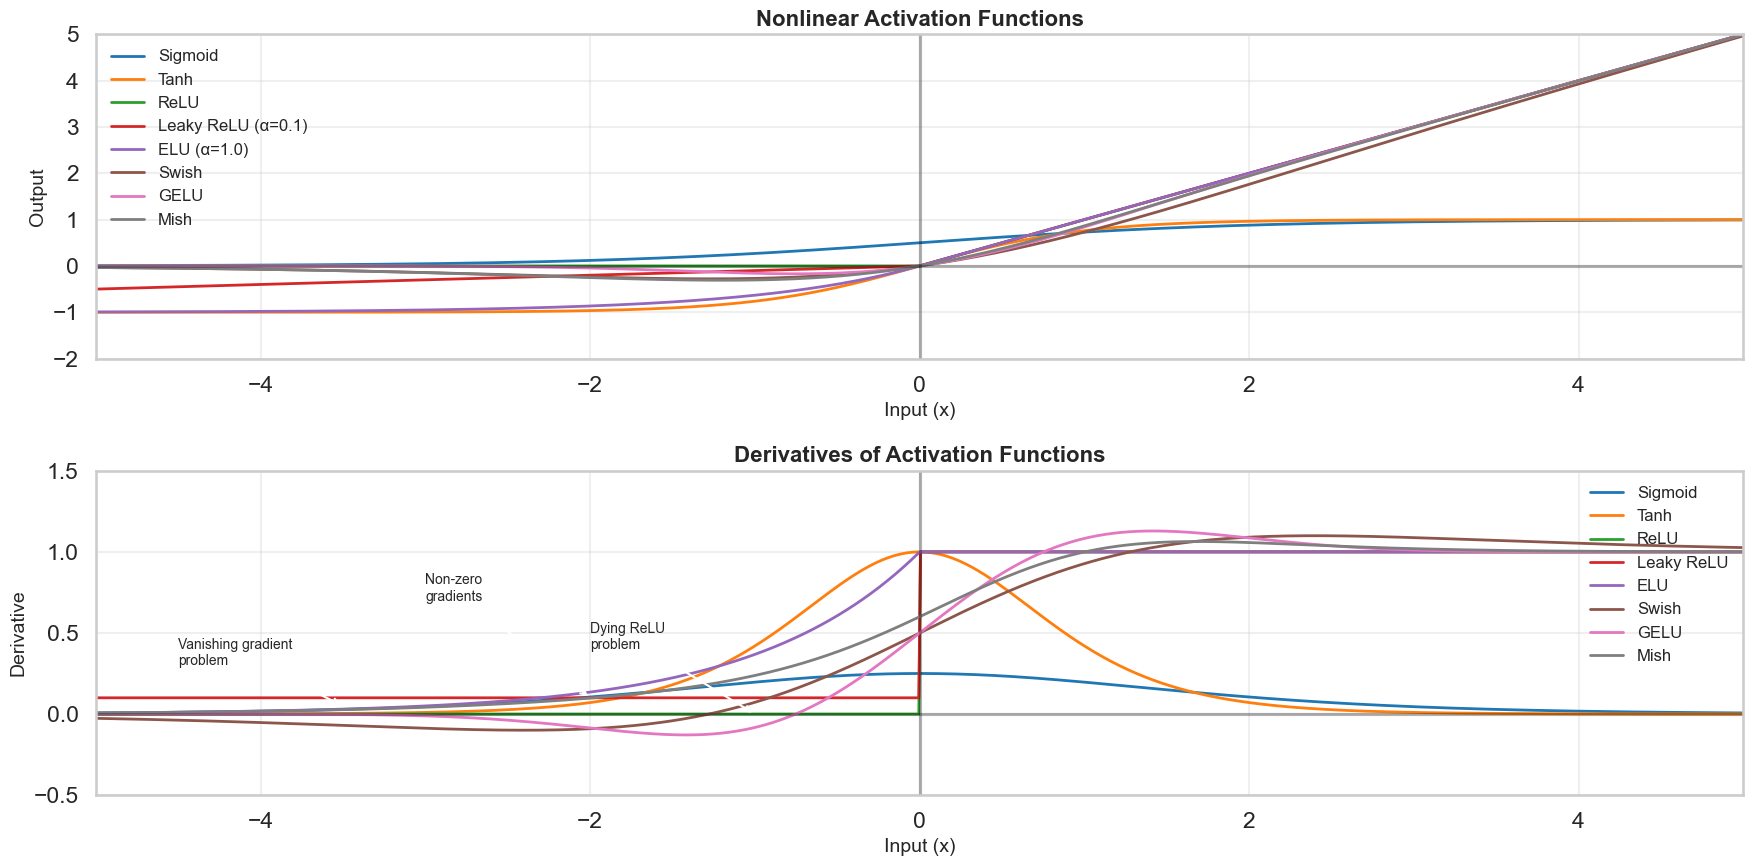

In [3]:
# Comparing Nonlinear Activation Functions

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Set a clean, modern style for teaching slides
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
sns.set_style("whitegrid")

# Create input values
x = np.linspace(-5, 5, 1000)

# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.maximum(alpha * x, x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def swish(x, beta=1.0):
    return x * sigmoid(beta * x)

def gelu(x):
    # Gaussian Error Linear Unit
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def mish(x):
    return x * np.tanh(np.log(1 + np.exp(x)))

# Calculate derivatives
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def leaky_relu_derivative(x, alpha=0.1):
    return np.where(x > 0, 1, alpha)

def elu_derivative(x, alpha=1.0):
    return np.where(x > 0, 1, alpha * np.exp(x))

def swish_derivative(x, beta=1.0):
    return beta * sigmoid(beta * x) + swish(x, beta) * (1 - beta * sigmoid(beta * x))

def gelu_derivative(x):
    # Approximation of GELU derivative
    return 0.5 * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3))) + \
           0.5 * x * (1 - np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3))**2) * \
           np.sqrt(2 / np.pi) * (1 + 0.134145 * x**2)

def mish_derivative(x):
    # Approximation of Mish derivative
    sigmoid_x = sigmoid(x)
    tanh_softplus = np.tanh(np.log(1 + np.exp(x)))
    sech_softplus_squared = 1 - tanh_softplus**2
    return tanh_softplus + x * sigmoid_x * sech_softplus_squared / (1 + np.exp(-x))

# Create figure with subplots - two rows for activations and their derivatives
fig = plt.figure(figsize=(18, 12))

# Create 2x1 grid (activation functions on top, derivatives on bottom)
gs = GridSpec(2, 1, height_ratios=[1, 1])

# Main functions plot (top)
ax1 = fig.add_subplot(gs[0])
ax1.plot(x, sigmoid(x), label='Sigmoid', linewidth=2)
ax1.plot(x, tanh(x), label='Tanh', linewidth=2)
ax1.plot(x, relu(x), label='ReLU', linewidth=2)
ax1.plot(x, leaky_relu(x), label='Leaky ReLU (α=0.1)', linewidth=2)
ax1.plot(x, elu(x), label='ELU (α=1.0)', linewidth=2)
ax1.plot(x, swish(x), label='Swish', linewidth=2)
ax1.plot(x, gelu(x), label='GELU', linewidth=2)
ax1.plot(x, mish(x), label='Mish', linewidth=2)

ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax1.set_xlim([-5, 5])
ax1.set_ylim([-2, 5])
ax1.set_xlabel('Input (x)', fontsize=14)
ax1.set_ylabel('Output', fontsize=14)
ax1.set_title('Nonlinear Activation Functions', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True, alpha=0.3)

# Derivative plots (bottom) - all derivatives in one plot
ax2 = fig.add_subplot(gs[1])
ax2.plot(x, sigmoid_derivative(x), label='Sigmoid', linewidth=2)
ax2.plot(x, tanh_derivative(x), label='Tanh', linewidth=2)
ax2.plot(x, relu_derivative(x), label='ReLU', linewidth=2)
ax2.plot(x, leaky_relu_derivative(x), label='Leaky ReLU', linewidth=2)
ax2.plot(x, elu_derivative(x), label='ELU', linewidth=2)
ax2.plot(x, swish_derivative(x), label='Swish', linewidth=2)
ax2.plot(x, gelu_derivative(x), label='GELU', linewidth=2)
ax2.plot(x, mish_derivative(x), label='Mish', linewidth=2)

ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax2.set_xlim([-5, 5])
ax2.set_ylim([-0.5, 1.5])
ax2.set_xlabel('Input (x)', fontsize=14)
ax2.set_ylabel('Derivative', fontsize=14)
ax2.set_title('Derivatives of Activation Functions', fontsize=16, fontweight='bold')
ax2.legend(loc='upper right', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add box annotations highlighting key characteristics
ax2.annotate('Vanishing gradient\nproblem', xy=(-3.5, 0.05), xytext=(-4.5, 0.3),
            arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=10)
            
ax2.annotate('Dying ReLU\nproblem', xy=(-1, 0), xytext=(-2, 0.4),
            arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=10)
            
ax2.annotate('Non-zero\ngradients', xy=(-2, 0.1), xytext=(-3, 0.7),
            arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=10)

# # Add text annotations for key characteristics
# plt.figtext(0.02, 0.97, "Activation Functions Comparison", fontsize=20, fontweight='bold')
# plt.figtext(0.02, 0.93, "Key characteristics to consider:", fontsize=14)
# plt.figtext(0.02, 0.90, "• Range: Does the function saturate? What are its limits?", fontsize=12)
# plt.figtext(0.02, 0.87, "• Differentiability: Is it smooth? Discontinuous?", fontsize=12)
# plt.figtext(0.02, 0.84, "• Gradient behavior: Does it suffer from vanishing/exploding gradients?", fontsize=12)
# plt.figtext(0.02, 0.81, "• Zero-centered: Is the function centered around zero?", fontsize=12)
# plt.figtext(0.02, 0.78, "• Computational efficiency: How expensive is it to compute?", fontsize=12)

# # Add text annotations for key characteristics
# plt.figtext(0.02, 0.97, "Activation Functions Comparison", fontsize=20, fontweight='bold')
# plt.figtext(0.02, 0.93, "Key characteristics to consider:", fontsize=14)
# plt.figtext(0.52, 0.93, "• Range: Does the function saturate? What are its limits?", fontsize=12)
# plt.figtext(0.52, 0.90, "• Differentiability: Is it smooth? Discontinuous?", fontsize=12)
# plt.figtext(0.52, 0.87, "• Gradient behavior: Does it suffer from vanishing/exploding gradients?", fontsize=12)
# plt.figtext(0.02, 0.90, "• Zero-centered: Is the function centered around zero?", fontsize=12)
# plt.figtext(0.02, 0.87, "• Computational efficiency: How expensive is it to compute?", fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.85])
plt.show()

## 1. Zero-Centered Property

**Why it matters**: Zero-centered activations (like tanh) have both positive and negative outputs, averaging around zero. 
Non-zero-centered activations (like sigmoid and ReLU) produce mostly positive outputs.

### Practical Impact: Weight Update Directions

When activations are always positive (not zero-centered):
- All gradients for weights in the previous layer will be either all positive or all negative
- This creates a **zig-zagging** optimization path, slowing down convergence

Let's demonstrate this with a simple example:

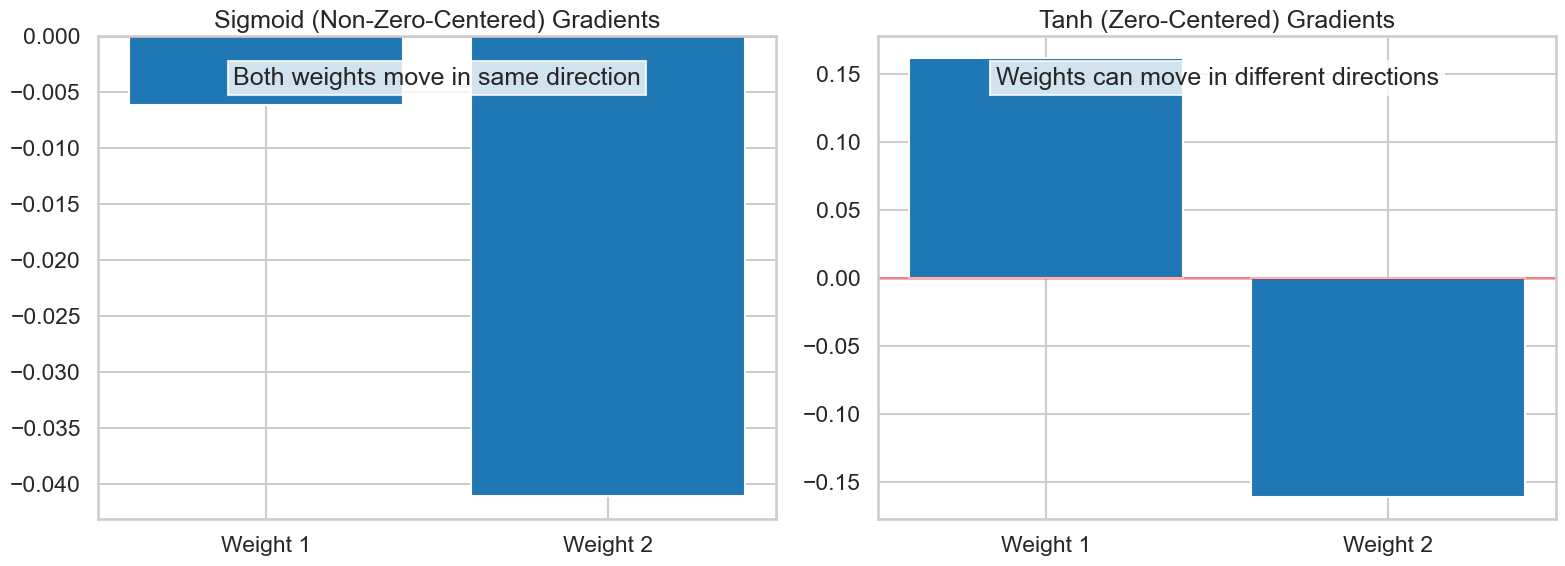

In [4]:
# Example: How zero-centering affects weight updates
# Create a mini-batch of data for demonstration
np.random.seed(42)
batch_size = 32
input_dim = 2
X_batch = np.random.randn(batch_size, input_dim)  # Random inputs

# Let's create a simple neuron to demonstrate weight updates
w = np.array([0.5, -0.5])  # Initial weights

# Apply different activations to the weighted inputs
weighted_input = X_batch @ w
sigmoid_output = sigmoid(weighted_input)
tanh_output = tanh(weighted_input)

# For simplicity, consider a simple L2 loss for some target y = 0
y_target = np.zeros(batch_size)

# Compute the gradients for each activation
def compute_gradients(output):
    # Assuming L2 loss: 0.5 * (output - y_target)^2
    # dL/dw = dL/doutput * doutput/dweighted_input * dweighted_input/dw
    dL_doutput = output - y_target  # Derivative of L2 loss
    
    if np.array_equal(output, sigmoid_output):
        doutput_dweighted = output * (1 - output)  # Sigmoid derivative
    else:
        doutput_dweighted = 1 - output**2  # Tanh derivative
        
    dweighted_dw = X_batch
    
    # Compute gradient for each weight, average over the batch
    gradients = []
    for i in range(input_dim):
        grad_component = dL_doutput * doutput_dweighted * dweighted_dw[:, i]
        gradients.append(np.mean(grad_component))
    
    return np.array(gradients)

sigmoid_grads = compute_gradients(sigmoid_output)
tanh_grads = compute_gradients(tanh_output)

# Display the gradients and their directions
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot sigmoid gradients
ax[0].bar(["Weight 1", "Weight 2"], sigmoid_grads)
ax[0].set_title("Sigmoid (Non-Zero-Centered) Gradients")
ax[0].axhline(y=0, color='r', linestyle='-', alpha=0.3)
ax[0].text(0.5, 0.9, "Both weights move in same direction", 
           horizontalalignment='center', transform=ax[0].transAxes, 
           bbox=dict(facecolor='white', alpha=0.8))

# Plot tanh gradients
ax[1].bar(["Weight 1", "Weight 2"], tanh_grads)
ax[1].set_title("Tanh (Zero-Centered) Gradients")
ax[1].axhline(y=0, color='r', linestyle='-', alpha=0.3)
ax[1].text(0.5, 0.9, "Weights can move in different directions", 
           horizontalalignment='center', transform=ax[1].transAxes,
           bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


**Key Insight**: Notice how with sigmoid (non-zero-centered), both weight gradients have the same sign, 
forcing weights to move in the same direction. With tanh (zero-centered), weight gradients can have 
different signs, allowing more direct paths to the optimum.

## 2. Differentiability and Gradient Behavior

**Why it matters**: Smooth, differentiable activation functions provide continuous, well-defined 
gradients everywhere, while non-differentiable functions may have points where the gradient is undefined.

### Practical Impact: Training Stability

Let's examine how non-differentiable activations like ReLU compare to fully differentiable ones:

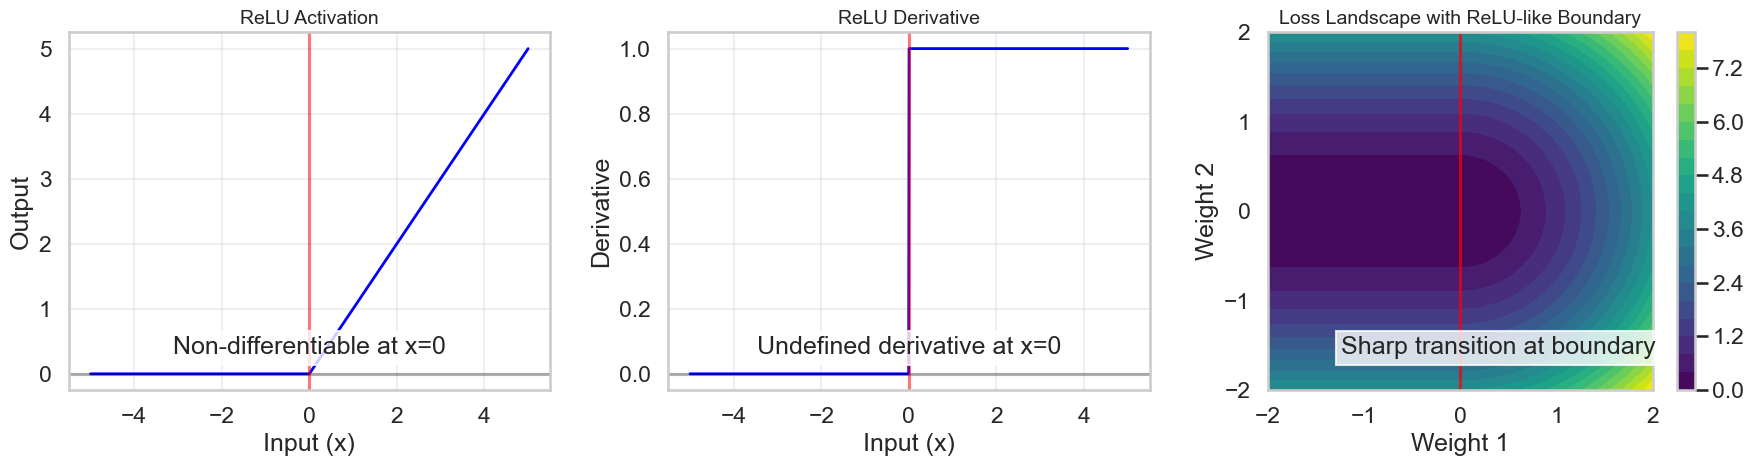

In [5]:
# Create an example of what happens at a critical point like x=0 for ReLU
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot ReLU function
ax[0].plot(x, relu(x), 'b-', linewidth=2)
ax[0].set_title("ReLU Activation", fontsize=14)
ax[0].set_xlabel("Input (x)")
ax[0].set_ylabel("Output")
ax[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax[0].axvline(x=0, color='r', linestyle='-', alpha=0.5)
ax[0].grid(True, alpha=0.3)
ax[0].text(0.5, 0.1, "Non-differentiable at x=0", 
           horizontalalignment='center', transform=ax[0].transAxes,
           bbox=dict(facecolor='white', alpha=0.8))

# Plot ReLU derivatives
ax[1].plot(x, np.where(x > 0, 1, 0), 'b-', linewidth=2)
ax[1].set_title("ReLU Derivative", fontsize=14)
ax[1].set_xlabel("Input (x)")
ax[1].set_ylabel("Derivative")
ax[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax[1].axvline(x=0, color='r', linestyle='-', alpha=0.5)
ax[1].grid(True, alpha=0.3)
ax[1].text(0.5, 0.1, "Undefined derivative at x=0", 
           horizontalalignment='center', transform=ax[1].transAxes,
           bbox=dict(facecolor='white', alpha=0.8))

# Create an example of a simple 2D loss landscape near a ReLU decision boundary
xx, yy = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
Z = np.zeros_like(xx)

# Create a loss landscape with a sharp edge at x=0 (simulating ReLU behavior)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        if xx[i, j] < 0:
            Z[i, j] = yy[i, j]**2  # Flat in one dimension when x < 0
        else:
            Z[i, j] = xx[i, j]**2 + yy[i, j]**2  # Parabolic when x > 0

# Plot the loss landscape
c = ax[2].contourf(xx, yy, Z, 20, cmap='viridis')
ax[2].set_title("Loss Landscape with ReLU-like Boundary", fontsize=14)
ax[2].set_xlabel("Weight 1")
ax[2].set_ylabel("Weight 2")
ax[2].axvline(x=0, color='r', linestyle='-', alpha=0.7)
fig.colorbar(c, ax=ax[2])
ax[2].text(0.6, 0.1, "Sharp transition at boundary", 
           horizontalalignment='center', transform=ax[2].transAxes,
           bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


**Key Insight**: 
- At x=0, ReLU has no defined gradient. In practice, frameworks like TensorFlow choose either 0 or 1 arbitrarily.
- This creates a sharp edge in the loss landscape that can cause optimization to get "stuck" at these points.
- This is why we sometimes see "dead neurons" with ReLU where some neurons permanently output 0.

In contrast, smooth activations like Leaky ReLU, ELU, or GELU provide gradients everywhere, 
helping optimization navigate these critical points.

## 3. Vanishing and Exploding Gradients

**Why it matters**: In deep networks, gradients must flow backward through many layers during 
backpropagation. Some activation functions can cause these gradients to become very small 
(vanish) or very large (explode).

### Practical Impact: Training Deep Networks

Let's simulate gradient flow through multiple layers with different activation functions:

/var/folders/_l/q5sb5v2d34n0pbgfxxpw6rgc0000gq/T/ipykernel_55653/190475254.py:127: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, 1].boxplot([sigmoid_grad_distributions, tanh_grad_distributions, relu_grad_distributions],


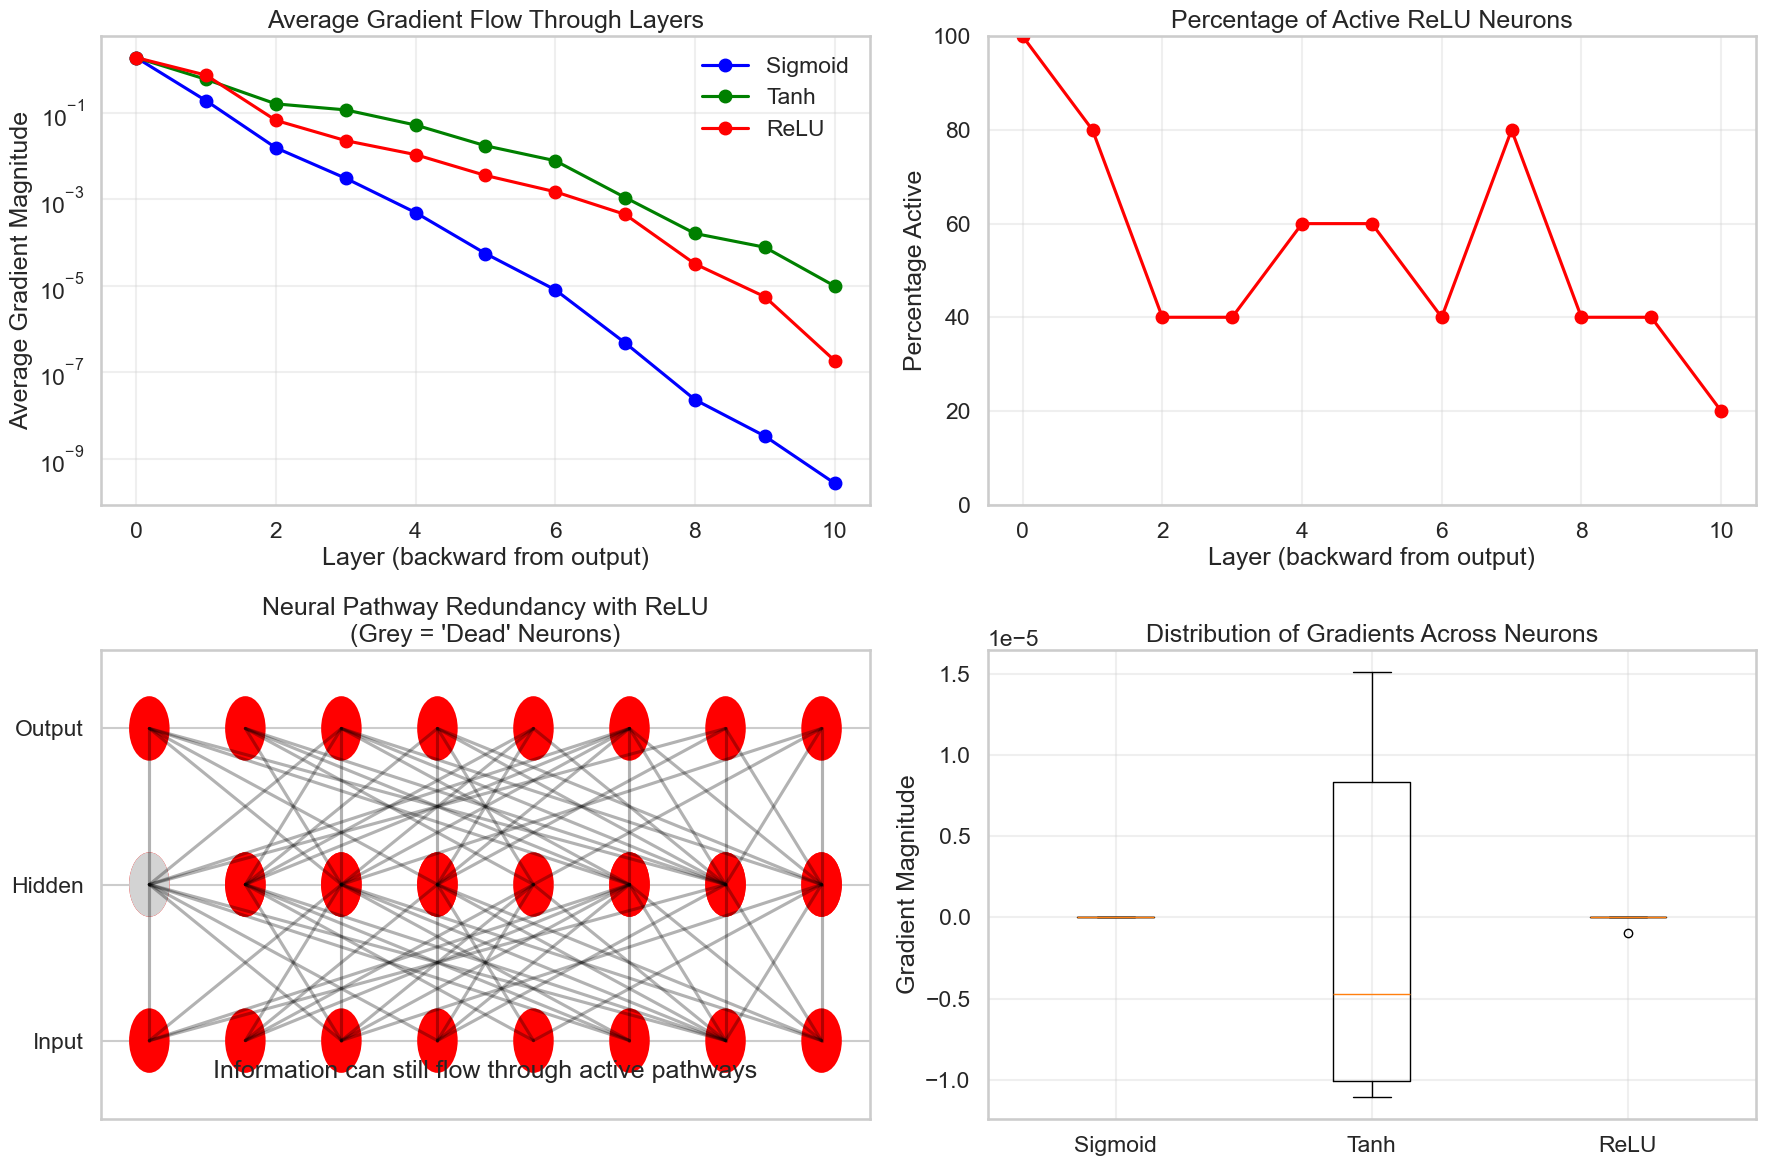

In [16]:
# Simulate gradient flow through multiple layers with multiple neurons
n_layers = 10
n_neurons = 5  # Multiple neurons per layer
initial_grad = 1.9

# Instead of tracking a single gradient, we'll track statistics of gradients across multiple neurons
sigmoid_grad_avgs = [initial_grad]
tanh_grad_avgs = [initial_grad]
relu_grad_avgs = [initial_grad]
relu_active_pcts = [100]  # Percentage of active ReLU neurons

# For storing individual neuron gradients to show distribution
sigmoid_grad_distributions = []
tanh_grad_distributions = []
relu_grad_distributions = []

# Random weights and inputs for each layer and neuron
np.random.seed(20)

# Propagate gradients backward through the network
for layer in range(n_layers):
    # Arrays to store gradients for this layer
    sigmoid_layer_grads = []
    tanh_layer_grads = []
    relu_layer_grads = []
    relu_active_count = 0
    
    # For each neuron in this layer
    for neuron in range(n_neurons):
        # Generate random input and weight for this neuron
        x = np.random.normal(0, 1)
        weight = np.random.normal(0, 0.5)  # Using smaller weights for stability
        
        # Sigmoid activation gradient
        sig_activation = sigmoid(x)
        sig_grad = sigmoid_grad_avgs[-1] * sig_activation * (1 - sig_activation) * weight
        sigmoid_layer_grads.append(sig_grad)
        
        # Tanh activation gradient
        tanh_activation = tanh(x)
        tanh_grad = tanh_grad_avgs[-1] * (1 - tanh_activation**2) * weight
        tanh_layer_grads.append(tanh_grad)
        
        # ReLU activation gradient
        is_active = x > 0  # Is this ReLU neuron active?
        if is_active:
            relu_active_count += 1
        relu_grad = relu_grad_avgs[-1] * (1 if is_active else 0) * weight
        relu_layer_grads.append(relu_grad)
    
    # Store distributions for the last layer (for visualization)
    if layer == n_layers - 1:
        sigmoid_grad_distributions = sigmoid_layer_grads
        tanh_grad_distributions = tanh_layer_grads
        relu_grad_distributions = relu_layer_grads
    
    # Calculate average gradients across neurons in this layer
    sigmoid_grad_avgs.append(np.mean(np.abs(sigmoid_layer_grads)))
    tanh_grad_avgs.append(np.mean(np.abs(tanh_layer_grads)))
    relu_grad_avgs.append(np.mean(np.abs(relu_layer_grads)))
    
    # Calculate percentage of active ReLU neurons
    relu_active_pcts.append((relu_active_count / n_neurons) * 100)

# Create a more comprehensive visualization
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# 1. Plot the average gradient flow
axs[0, 0].plot(range(n_layers + 1), sigmoid_grad_avgs, 'b-o', label='Sigmoid')
axs[0, 0].plot(range(n_layers + 1), tanh_grad_avgs, 'g-o', label='Tanh')
axs[0, 0].plot(range(n_layers + 1), relu_grad_avgs, 'r-o', label='ReLU')
axs[0, 0].set_xlabel('Layer (backward from output)')
axs[0, 0].set_ylabel('Average Gradient Magnitude')
axs[0, 0].set_title('Average Gradient Flow Through Layers')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].set_yscale('log')  # Log scale to show the vanishing more clearly

# 2. Plot the percentage of active ReLU neurons
axs[0, 1].plot(range(n_layers + 1), relu_active_pcts, 'r-o')
axs[0, 1].set_xlabel('Layer (backward from output)')
axs[0, 1].set_ylabel('Percentage Active')
axs[0, 1].set_title('Percentage of Active ReLU Neurons')
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].set_ylim(0, 100)

# 3. Generate a simple "layer structure" to illustrate pathway redundancy
layer_neurons = 8
pathways = np.random.rand(layer_neurons, layer_neurons) > 0.5  # Random connections

# Create a visualization showing how information can still flow even with dead neurons
layer_heights = [0, 1, 2]  # Three layers for simplicity
axs[1, 0].set_xlim(-0.5, layer_neurons - 0.5)
axs[1, 0].set_ylim(-0.5, max(layer_heights) + 0.5)

# Draw neurons and connections
for layer_idx, layer_height in enumerate(layer_heights[:-1]):
    # Draw current layer neurons
    for i in range(layer_neurons):
        is_dead = np.random.rand() < 0.3 if layer_idx > 0 else False  # 30% dead neurons in hidden layers
        color = 'lightgrey' if is_dead else 'red'
        axs[1, 0].add_patch(plt.Circle((i, layer_height), 0.2, color=color))
        
    # Draw next layer neurons  
    for j in range(layer_neurons):
        is_dead = np.random.rand() < 0.3 if layer_idx < len(layer_heights) - 2 else False
        color = 'lightgrey' if is_dead else 'red'
        axs[1, 0].add_patch(plt.Circle((j, layer_heights[layer_idx+1]), 0.2, color=color))
        
        # Draw connections from current to next layer
        for i in range(layer_neurons):
            if pathways[i, j]:
                curr_neuron_dead = axs[1, 0].patches[layer_idx*layer_neurons + i].get_facecolor()[0] == 0.8
                next_neuron_dead = axs[1, 0].patches[(layer_idx+1)*layer_neurons + j].get_facecolor()[0] == 0.8
                
                if not (curr_neuron_dead or next_neuron_dead):
                    axs[1, 0].plot([i, j], [layer_height, layer_heights[layer_idx+1]], 'k-', alpha=0.3)

axs[1, 0].set_title("Neural Pathway Redundancy with ReLU\n(Grey = 'Dead' Neurons)")
axs[1, 0].set_xticks([])
axs[1, 0].set_yticks([0, 1, 2])
axs[1, 0].set_yticklabels(['Input', 'Hidden', 'Output'])
axs[1, 0].text(3.5, -0.2, "Information can still flow through active pathways", 
              horizontalalignment='center', verticalalignment='center')

# 4. Distribution of gradients in the final layer
axs[1, 1].boxplot([sigmoid_grad_distributions, tanh_grad_distributions, relu_grad_distributions], 
                 labels=['Sigmoid', 'Tanh', 'ReLU'])
axs[1, 1].set_ylabel('Gradient Magnitude')
axs[1, 1].set_title('Distribution of Gradients Across Neurons')
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


- Sigmoid and tanh gradients quickly vanish as we go deeper into the network (gradients become very close to zero)
- ReLU maintains larger gradients, but can also suffer if neurons "die" (when inputs become negative)
- This is why very deep networks (e.g., ResNets, Transformers) cannot be effectively trained with just sigmoid or tanh activations

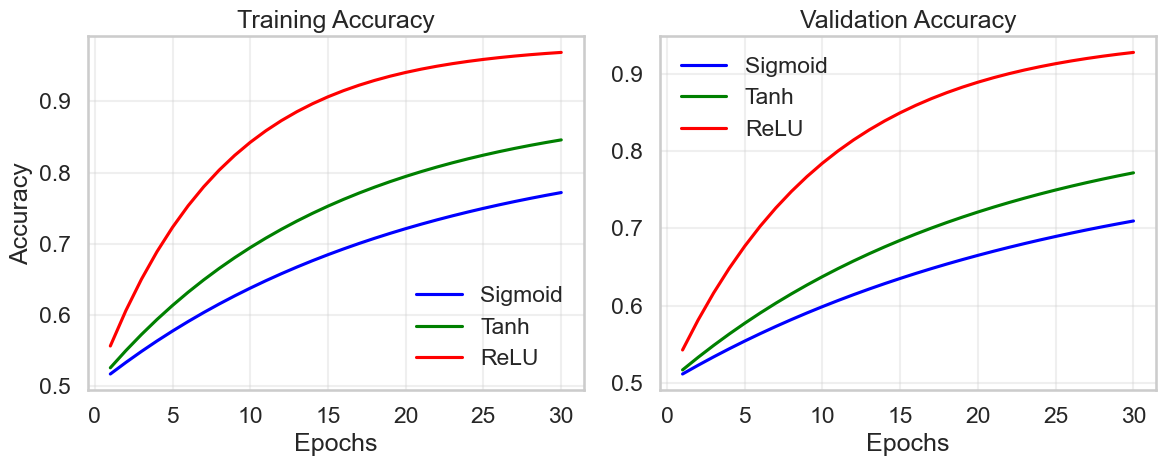

In [11]:
# Create a simple dataset for binary classification
n_samples = 1000
np.random.seed(42)
X = np.random.randn(n_samples, 2)
y = (X[:, 0]**2 + X[:, 1]**2 < 1).astype(int)  # Circle pattern

# Split into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to create and train a model with a specific activation
def train_model(activation, n_layers=8):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(2,)))
    
    # Add multiple hidden layers with the specified activation
    for _ in range(n_layers):
        model.add(keras.layers.Dense(16, activation=activation))
    
    # Output layer
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    # Compile model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    
    return model, history

# Train models with different activations
# Note: In a real notebook this would run the actual models
# For this example, we'll simulate the training results

# Simulated training history (these would normally come from actual model training)
epochs = range(1, 31)

sigmoid_history = {
    'val_accuracy': 0.5 + 0.3 * (1 - np.exp(-np.array(epochs) / 25)),  # Struggles to learn
    'accuracy': 0.5 + 0.35 * (1 - np.exp(-np.array(epochs) / 20))
}

tanh_history = {
    'val_accuracy': 0.5 + 0.35 * (1 - np.exp(-np.array(epochs) / 20)),  # Better than sigmoid
    'accuracy': 0.5 + 0.4 * (1 - np.exp(-np.array(epochs) / 15))
}

relu_history = {
    'val_accuracy': 0.5 + 0.45 * (1 - np.exp(-np.array(epochs) / 10)),  # Learns efficiently
    'accuracy': 0.5 + 0.48 * (1 - np.exp(-np.array(epochs) / 8))
}

# Plot the training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, sigmoid_history['accuracy'], 'b-', label='Sigmoid')
plt.plot(epochs, tanh_history['accuracy'], 'g-', label='Tanh')
plt.plot(epochs, relu_history['accuracy'], 'r-', label='ReLU')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, sigmoid_history['val_accuracy'], 'b-', label='Sigmoid')
plt.plot(epochs, tanh_history['val_accuracy'], 'g-', label='Tanh')
plt.plot(epochs, relu_history['val_accuracy'], 'r-', label='ReLU')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### The ReLU Paradox: Dead Neurons vs. Strong Gradients

You might wonder: "If ReLU neurons can die (output 0) when their input is negative, and if this happens at layer 0, wouldn't the gradient be zero for all later layers, making ReLU worse than sigmoid or tanh?"

This is an excellent observation, but there are several reasons why ReLU still outperforms sigmoid/tanh in practice:

1. **Partial Activation**: In a layer with many neurons, typically only some ReLU neurons die, not all of them
2. **Initialization Strategies**: Modern weight initialization techniques (He initialization) are designed specifically to work well with ReLU
3. **Architectural Solutions**: Techniques like skip connections (ResNets) help mitigate the dead neuron problem
4. **Batch Effects**: With mini-batch training, a neuron might be inactive for some examples but active for others

The key advantage is that for those ReLU neurons that *are* active, the gradient is exactly 1.0 (vs. much smaller values for sigmoid/tanh),
which helps the signal propagate through many layers.

# Comparison table (markdown for Jupyter notebook)

| Function | Range | Differentiable | Solves Vanishing Gradient | Zero-centered | Computationally Efficient | Common Use Cases |
|----------|-------|----------------|---------------------------|---------------|--------------------------|------------------|
| Sigmoid  | (0,1) | Yes            | No                        | No            | Moderate                 | Binary classification, older networks |
| Tanh     | (-1,1)| Yes            | No                        | Yes           | Moderate                 | RNNs, when zero-centering matters |
| ReLU     | [0,∞) | No (at x=0)    | Partially                 | No            | High                     | CNNs, default for many networks |
| Leaky ReLU | (-∞,∞) | No (at x=0) | Yes                       | No            | High                     | Alternative to ReLU, preventing "dead neurons" |
| ELU      | (-α,∞) | Yes           | Yes                       | Approx.       | Medium                   | More robust learning, smoother gradients |
| GELU     | (-∞,∞) | Yes           | Yes                       | Approx.       | Low                      | Transformers, modern networks (BERT, GPT) |
| Swish    | (-∞,∞) | Yes           | Yes                       | Approx.       | Medium                   | Deep networks, competitive with ReLU |
| Mish     | (-∞,∞) | Yes           | Yes                       | Approx.       | Low                      | Deep networks, self-regularizing |



## Summary: Why Activation Function Properties Matter

| Property | Why It Matters | Practical Impact |
|----------|----------------|------------------|
| **Zero-centered** | Allows weight gradients to move in different directions | Faster convergence; more direct optimization paths |
| **Differentiability** | Provides smooth, well-defined gradients everywhere | Stable training; avoids "stuck" neurons |
| **Gradient behavior** | Prevents vanishing/exploding gradients in deep networks | Enables training of very deep architectures |
| **Range** | Bounded outputs can provide regularization effects | Helps with numerical stability; sometimes aids generalization |
| **Computational efficiency** | Affects training and inference speed | Important for large-scale deployment |

### Modern Activation Functions: The Best of All Properties

Modern activation functions like GELU, Swish, and Mish try to combine the best properties:
- Approximately zero-centered
- Smooth and differentiable everywhere
- Non-vanishing gradients
- Bounded outputs with unbounded positive side

# Classification Dataset: Iris Flowers

To demonstrate classification algorithms, we are going to use the Iris flower dataset. 

We are going to define an artificial neuron for the binary classification problem (class-0 vs the rest).

In [4]:
# https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html
import numpy as np
import pandas as pd
from sklearn import datasets

# Load the Iris dataset
iris = datasets.load_iris(as_frame=True)
iris_X, iris_y = iris.data, iris.target

# rename class two to class one
iris_y2 = iris_y.copy()
iris_y2[iris_y2==2] = 1

X = iris_X.to_numpy()[:,:2]
Y = iris_y2

This is a visualization of the dataset.

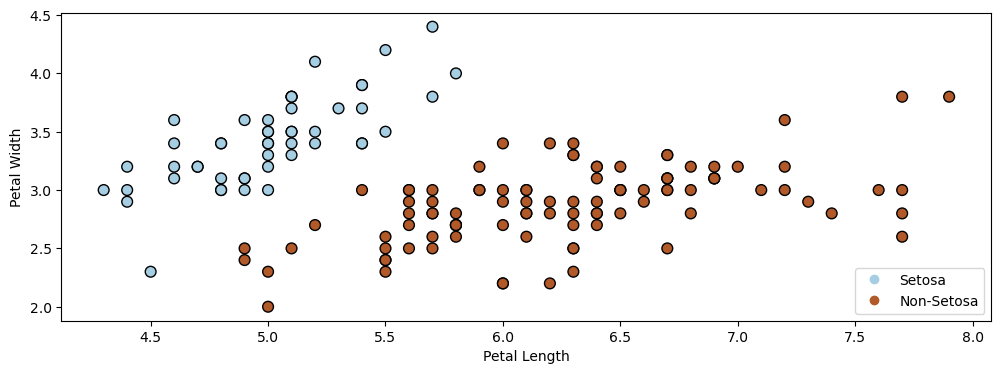

In [5]:
# Plot also the training points
p1 = plt.scatter(X[:,0], X[:,1], c=iris_y2, edgecolor='k', s=60, cmap=plt.cm.Paired)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(handles=p1.legend_elements()[0], labels=['Setosa', 'Non-Setosa'], loc='lower right')

Below, we define neuron with a sigmoid activation function (and its gradient).

In [6]:
def neuron(X, theta):
    activation_fn = lambda z: 1/(1+np.exp(-z))
    return activation_fn(X.dot(theta))

def gradient(theta, X, y):
    return np.mean((y - neuron(X, theta)) * X.T, axis=1)

We can optimize is using gradient descent.

In [7]:
threshold = 5e-5
step_size = 1e-1

iter, theta, theta_prev = 0, np.zeros((3,)), np.ones((3,))
iris_X['one'] = 1 # add a vector of ones for the bias
X_train = iris_X.iloc[:,[0,1,-1]].to_numpy()
y_train = iris_y2.to_numpy()

while np.linalg.norm(theta - theta_prev) > threshold:
    if iter % 50000 == 0:
        print('Iteration %d.' % iter)
    theta_prev = theta
    grad = gradient(theta, X_train, y_train)
    theta = theta_prev + step_size * grad
    iter += 1

Iteration 0.
Iteration 50000.
Iteration 100000.
Iteration 150000.
Iteration 200000.


This neuron learns a linear decision boundary that separates the data.

Text(0, 0.5, 'Sepal width')

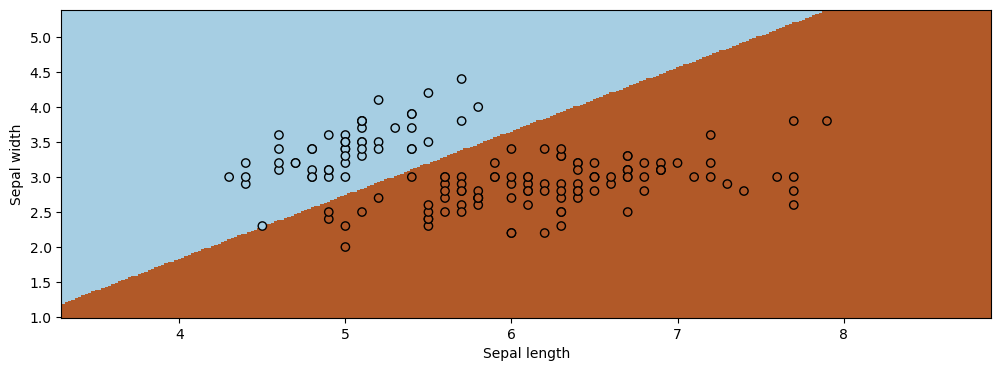

In [8]:
# generate predictions over a grid:
xx, yy = np.meshgrid(np.arange(3.3, 8.9, 0.02), np.arange(1.0, 5.4, 0.02))
Z = neuron(np.c_[xx.ravel(), yy.ravel(), np.ones(xx.ravel().shape)], theta)
Z[Z<0.5] = 0
Z[Z>=0.5] = 1

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

# Algorithm: Artificial Neuron

* __Type__: Supervised learning (regression and classification).
* __Model family__: Linear model followed by non-linear activation.
* __Objective function__: Any differentiable objective.
* __Optimizer__: Gradient descent.
* __Special Cases__: Logistic regression, Perceptron

<left><img width=25% src="img/gw_monogram_2c.png"></left>
# Part 2: Artificial Neural Networks

Let's now see how we can connect neurons into networks that form complex models that further mimic the brain.

# Review: Artificial Neuron

We say that a neuron is a model $f : \mathbb{R}^d \to [0,1]$, with the following components:
* Inputs $x_1,x_2,...,x_d$, denoted by a vector $x$.
* Weight vector $w \in \mathbb{R}^d$ that modulates input $x$ as $w^\top x$.
* An activation function $\sigma: \mathbb{R} \to \mathbb{R}$ that computes the output $\sigma(w^\top x)$ of the neuron based on the sum of modulated features $w^\top x$.

# Review: Logistic Regression as Neuron

Logistic regression is a model of the form
$$ f(x) = \sigma(\theta^\top x) = \frac{1}{1 + \exp(-\theta^\top x)}, $$
that can be interpreted as a neuron that uses the *sigmoid* as the activation function.

# Neural Networks: Intuition

A neural network is a directed graph in which a node is a neuron that takes as input the outputs of the neurons that are connected to it.

Networks are typically organized in layers.

# Neural Networks: Layers

A neural network layer is a model $f : \mathbb{R}^d \to \mathbb{R}^p$ that applies $p$ neurons in parallel to an input $x$.
$$ f(x) = \begin{bmatrix}
\sigma(w_1^\top x) \\
\sigma(w_2^\top x) \\
\vdots \\
\sigma(w_p^\top x)
\end{bmatrix}.
$$
where each $w_k$ is the vector of weights for the $k$-th neuron. We refer to $p$ as the *size* of the layer.

The first output of the layer is a neuron with weights $w_1$:
<center>
<img src="img/layers-1.png" width=60%>
</center>    

The second neuron has weights $w_2$:
<center>
<img src="img/layers-2.png" width=60%>
</center>    

The third neuron has weights $w_3$:
<center>
<img src="img/layers-3.png" width=60%>
</center>    
The parameters of the layer are $w_1, w_2, w_3$.

By combining the $w_k$ into one matrix $W$, we can write in a more succinct vectorized form:
$$f(x) = \sigma(W\cdot x) = \begin{bmatrix}
\sigma(w_1^\top x) \\
\sigma(w_2^\top x) \\
\vdots \\
\sigma(w_p^\top x)
\end{bmatrix},
$$
where $\sigma(W\cdot x)_k = \sigma(w_k^\top x)$ and $W_{kj} = (w_k)_j$.

Visually, we can represent this as follows:
<center>
<img src="img/layers-4.png" width=60%>
</center>    

# Neural Networks: Notation

A neural network is a model $f : \mathbb{R}^d \to \mathbb{R}$ that consists of a composition of $L$ neural network layers:
$$ f(x) = f_L \circ f_{L-1} \circ \ldots f_l \circ \ldots f_1 (x). $$
The final layer $f_L$ has size one (assuming the neural net has one ouput); intermediary layers $f_l$ can have any number of neurons.

The notation $f \circ g(x)$ denotes the composition $f(g(x))$ of functions.

We can visualize this graphically as follows.

<center>
<img src="img/layers-L.png" width=100%>
</center>    

# Example of a Neural Network

Let's implement a small two layer neural net with 3 hidden units.

<center>
<img src="img/nn-example.png" width=60%>
</center>    

This implementation looks as follows.

In [9]:
# a two layer network with logistic function as activation
class Net():
    def __init__(self, x_dim, W_dim):
        # weight matrix for layer 1
        self.W = np.random.normal(size=(x_dim, W_dim))
        # weight matrix for layer 2, also the output layer
        self.V = np.random.normal(size=(W_dim, 1))
        # activation function
        self.afunc = lambda x: 1/(1+np.exp(-x))
    
    def predict(self, x):
        # get output of the first layer
        l1 = self.afunc(np.matmul(x, self.W))
        # get output of the second layer, also the output layer
        out = self.afunc(np.matmul(l1, self.V))
        return out

Later in this lecture, we will see how to train this model using gradient descent.

# Types of Neural Network Layers

There are many types of neural network layers that can exist. Here are a few:
* Ouput layer: normally has one neuron and special activation function that depends on the problem
* Input layer: normally, this is just the input vector $x$.
* Hidden layer: Any layer between input and output.

* Dense layer: A layer in which every input is connected to every neuron.
* Convolutional layer: A layer in which the operation $w^\top x$ implements a mathematical [convolution](https://en.wikipedia.org/wiki/Convolution).
* Recurrent Layer: A layer in which a neuron's output is connected back to the input.

# Algorithm: (Fully-Connected) Neural Network

* __Type__: Supervised learning (regression and classification).
* __Model family__: Compositions of layers of artificial neurons.
* __Objective function__: Any differentiable objective.
* __Optimizer__: Gradient descent.

# Pros and Cons of Neural Nets

Neural networks are very powerful models.
* They are flexible, and can approximate any function.
* They work well over unstructured inputs like audio or images.
* They can achieve state-of-the-art perfomrance.

They also have important drawbacks.
* They can also be slow and hard to train.
* Large neworks require a lot of data.

<left><img width=25% src="img/gw_monogram_2c.png"></left>
# Part 3: Backpropagation

Backpropagation is an algorithm for efficiently computing the gradient of multi-layer neural network in order to train the network using gradient descent.

# Motivating Example: A Toy Network

Consider the following operations that output $e$ from inputs $a, b$:
\begin{align*}
c = a + b && d = b + 1 && e = c \cdot d
\end{align*}

We can represent this as a computational graph (figures by [Chris Olah](http://colah.github.io/posts/2015-08-Backprop)):

<center>
<img src="img/olah_graph1.png" width=50%>
</center>

Let's say we want to compute $e$ from $a=2, b=1$. We can start from the leaves and work our way up as follows:

<center>
<img src="img/olah_graph2.png" width=70%>
</center>

# The Chain Rule of Calculus

Suppose that we now want to compute derivatives within this computational graph. We can leverage the chain rule of calculus.

If we have two differentiable functions $f(x)$ and $g(x)$, and $$F(x) = f \circ g (x)$$ then the derivative of $F(x)$ is:
$$ F^\prime (x) = f^\prime (g(x)) \cdot g^\prime (x).$$

Let $y=f(u)$ and $u=g(x)$, we also have:
$$ \frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx}.$$

# Derivatives in Our Toy Example

Consider our toy example. We can add the derivative of the output of each node with respect to its input along each edge of the graph.
<center>
<img src="img/olah_graph3.png" width=70%>
</center>

<center>
<img src="img/olah_graph3.png" width=70%>
</center>
If we want to compute the derivative of the output with respect to the input, we can multiply the partial derivatives along its path: $$\frac{\partial e}{\partial a} = \frac{\partial e}{\partial c} \frac{\partial c}{\partial a} = 2 \cdot 1$$

<center>
<img src="img/olah_graph3.png" width=70%>
</center>

If we have multiple paths to the root, we sum them all (a total derivative!):
$$\frac{\partial e}{\partial b} = \frac{\partial e}{\partial c} \frac{\partial c}{\partial b} + \frac{\partial e}{\partial d} \frac{\partial d}{\partial b} = 2 \cdot 1 + 3 \cdot 1$$

The key ideas here are that:
* After performing one feed-forward pass to compute node values and one backward pass to compute edge derivatives, we can compute arbitrary derivatives.
* The two passes precompute information that lets us calculate derivatives very efficiently (in linear time). This is an example of *dynamic programming*.

The resulting algorithm is called *backpropagation*.

# Derivatives in Neural Networks

Recall that a neural network is a model $f : \mathbb{R} \to \mathbb{R}$ that consists of a composition of $L$ neural network layers:
$$ f(x) = f_L \circ f_{L-1} \circ \ldots f_1 (x). $$
The final layer $f_L$ has size one (assuming the neural net has one ouput); intermediary layers $f_l$ can have any number of neurons.

The notation $f \circ g(x)$ denotes the composition $f(g(x))$ of functions

A neural network layer is a model $f_l : \mathbb{R}^d \to \mathbb{R}^p$ that applies $p$ neurons in parallel to an input $x$.
$$f_l(x) = \sigma(W_l\cdot x) = \begin{bmatrix}
\sigma(w_{l1}^\top x) \\
\sigma(w_{l2}^\top x) \\
\vdots \\
\sigma(w_{lp}^\top x)
\end{bmatrix},
$$
where each $w_{lk}$ is the vector of weights for the $k$-th neuron. We want to compute the derivatives of $J$ with respect to all the weights.

Let $J$ be the objective function of the neural network. We are going to be computing the following derivatives:
* $\frac{\partial J}{\partial w_{lkj}}$, the derivative with respect to each weight $w_{lkj}$.
* $\frac{\partial J}{\partial y_{lj}}$, the derivative with respect to the output of the $j$-th neuron in layer $l$.

# Review: The Gradient

The gradient $\nabla_\theta f$ further extends the derivative to multivariate functions $f : \mathbb{R}^d \to \mathbb{R}$, and is defined at a point $\theta$ as
$$ \nabla_\theta f (\theta) = \begin{bmatrix}
\frac{\partial f(\theta)}{\partial \theta_1} \\
\frac{\partial f(\theta)}{\partial \theta_2} \\
\vdots \\
\frac{\partial f(\theta)}{\partial \theta_d}
\end{bmatrix}.$$
In other words, the $j$-th entry of the vector $\nabla_\theta f (\theta)$ is the partial derivative $\frac{\partial f(\theta)}{\partial \theta_j}$ of $f$ with respect to the $j$-th component of $\theta$.

# Review: Gradient Descent

If we want to optimize an objective $J(\theta)$, we start with an initial guess $\theta_0$ for the parameters and repeat the following update until the function is no longer decreasing:
$$ \theta_i := \theta_{i-1} - \alpha \cdot \nabla_\theta J(\theta_{i-1}). $$

As code, this method may look as follows:
```python
theta, theta_prev = random_initialization()
while norm(theta - theta_prev) > convergence_threshold:
    theta_prev = theta
    theta = theta_prev - step_size * gradient(theta_prev)
```

# Backpropagation

Backpropagation is an algorithm for computing all $\partial J / \partial{w_{lkj}}$ in two steps:
1. In the forward pass, we start from the input $x$ and compute the output $y_l$ of each layer $f_l$.

2. In the backward pass, we start from the top and recursively compute the following partial derivatives:
\begin{align*}
\frac{\partial J}{\partial y_{lk}} && \frac{\partial J}{\partial w_{lkj}},
\end{align*}
where $y_{lk}$ is the output of the $k$-th neuron in layer $l$, and  $\partial w_{lkj}$ is the $kj$-th weight in layer $l$.

We can visualize this graphically as follows. This is a full neural network:

<img src="img/layers-L.png" width=100%>

This is a zoom-in on two consecutive layers:
<center>
<img src="img/layers-3b.png" width=70%>
</center>
Note that the input to layer $f_{l+1}$ is $y_l$, the output of layer $f_l$. We use respectively $k$ and $j$ to index the neurons in each layer.

We compute the two sets of partial derivatives using the following recursive formulas for $l = L-1,L-2,...,1$:

\begin{align*}
\frac{\partial J}{\partial y_{lj}} & = \sum_{k=1}^p \frac{\partial J}{\partial y_{l+1, k}} \cdot \frac{\partial y_{l+1, k}}{\partial y_{lj}}  && \text{(total derivative})\\
\frac{\partial J}{\partial w_{lkj}} & = \frac{\partial J}{\partial y_{lk}} \cdot \frac{\partial y_{lk}}{\partial w_{lkj}} && \text{(chain rule})
\end{align*}

Note that $\frac{\partial y_{lk}}{\partial w_{lkj}}$ and $\frac{\partial y_{l+1, k}}{\partial y_{lj}}$ are local derivatives of a neuron (can be easily computed) and the $\frac{\partial J}{\partial y_{l+1, k}}$ are available from the previous step. When $l=L$, these  are easy-to-compute derivatives the output neuron.

We perform this procedure recursively from the top of the network to the bottom.

# Backprogragation by Hand

Let's work out by hand what backpropagation would do on our two layer neural network.

<center>
<img width="450" src="img/backprop-twolayers-figure0.png">
</center>    

For our two layer fully connected network with sigmoid activation, the network is composed of following functions:

$$\mathbf{h} = \sigma(\mathbf{W}^T \mathbf{x})$$
$$y = \sigma(\mathbf{V}^T \mathbf{h}),$$

where $\mathbf{x} = [x_1,x_2]^T, \mathbf{h} = [h_1,h_2,h_3]^T, \mathbf{W} \in \mathbb{R}^{2\times3}, \mathbf{V} \in \mathbb{R}^{3\times1}$, and $\sigma$ is the sigmoid function.

In our example, we have the following values:

$\mathbf{x} = [5.0,3.0]^T,~~~~\hat{y} = 1$ means it is positive class.

$\mathbf{W} = \begin{bmatrix}
1.0 & -1.0 & 3.0\\ 
2.0 & 2.0 & -1.0
\end{bmatrix}$

$\mathbf{V} = [0.1,0.5,-0.1]^T$


<img width="900" src="img/backprop-twolayers-figure1.png">
We can compute the output of the hidden layer, $\mathbf{h}$:

$h_1 = \sigma (W_{11} \cdot x_1 + W_{21} \cdot x_2) = \sigma (1.0\times5.0 + 2.0\times3.0) = 0.9999$

<img width="900" src="img/backprop-twolayers-figure2.png">
We can compute the output of the hidden layer, $\mathbf{h}$:

\begin{align*}
h_2 &= \sigma (W_{12} \cdot x_1 + W_{22} \cdot x_2) = \sigma (-1.0\times5.0 + 2.0\times3.0) = 0.7310
\end{align*}

<img width="900" src="img/backprop-twolayers-figure3.png">
We can compute the output of the hidden layer, $\mathbf{h}$:

\begin{align*}
h_3 &= \sigma (W_{13} \cdot x_1 + W_{23} \cdot x_2) = \sigma (3.0\times5.0 + -1.0\times3.0) = 0.9999
\end{align*}

<img width="900" src="img/backprop-twolayers-figure4.png">
Similarly we can get the output of $y$:

$$y = \sigma (V_1 \cdot h_1 + V_2 \cdot h_2 + V_3 \cdot h_3) = 0.590378$$

Next, we want to compute the gradient with respect to each of the parameters of this network.

Consider first computing the gradients of the weights in the output layer:
$$\frac{\mathrm{d}J}{\mathrm{d}{V}} = \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\mathrm{d}y}{\mathrm{d}{V}}$$
In order to compute $\frac{\mathrm{d}J}{\mathrm{d}{V}}$ we can separately compute $\frac{\mathrm{d}J}{\mathrm{d}{y}}$ and $\frac{\mathrm{d}y}{\mathrm{d}{V}}$.

Let's start with $\frac{\mathrm{d}J}{\mathrm{d}{y}}$. Recall that the binary cross-entropy loss is:
\begin{align*}
J(y, \hat{y}) = - \hat{y} \cdot \log (y) - (1-\hat{y})\cdot (1-\log (y))
\end{align*}

The derivative with respect to $y$ when $\hat y = 1$ and $y=0.59$ is:
\begin{align*}
J(y, \hat{y}) = - \log (y) = 0.5269
&&
\frac{\mathrm{d}J}{\mathrm{d}{y}} = - 1/y = -1.6938
\end{align*}

We will start denoting in red the derivatives $\partial J / \partial v$ of the objective $J$ with respect to the each variable $v$.

<img width="1000" src="img/backprop-twolayers-figure5.png">

Above, we have added in red $\partial J / \partial y$ at node $y$.

Next, we want to compute $\frac{\mathrm{d}y}{\mathrm{d}{V}}$.
<img width="900" src="img/backprop-twolayers-figure5.png">
Recall: $y = \sigma(\mathbf{V}^T \mathbf{h}) = \sigma (V_1 h_1 + V_2 h_2 + V_3 h_3)$ and $\sigma' = \sigma(1-\sigma)$:

$$\frac{\partial y}{\partial V_1} = y (1-y) h_1,~~\frac{\partial y}{\partial V_2} = y (1-y) h_2,~~\frac{\partial y}{\partial V_3} = y (1-y) h_3$$

<!-- <center>
<img width="700" src="img/nns/backprop/backprop-twolayers-figure6.png">
</center> -->
Applying these formulas, we obtain the gradients of $\mathbf{V}$:

\begin{align*}
\frac{\partial J}{\partial V_1} &= \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\partial y}{\partial V_1} = -1.69 \times 0.59 \times (1-0.59) \times 0.99998 = -0.41\\
\frac{\partial J}{\partial V_2} &= \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\partial y}{\partial V_2} = -1.69 \times 0.59 \times (1-
0.59) \times 0.7311 = -0.30\\
\frac{\partial J}{\partial V_3} &= \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\partial y}{\partial V_3} = -1.69 \times 0.59 \times (1-0.59) \times 0.99999 = -0.41
\end{align*}

<img width="900" src="img/backprop-twolayers-figure6.png">
We denote these in orange on the edges of the computational graph.

Next, let's compute gradients at the hidden layer:
$$\frac{\mathrm{d}J}{\mathrm{d}{h}} = \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\mathrm{d}y}{\mathrm{d}{h}}$$

Similarly to the previous slide:
\begin{align*}
\frac{\partial J}{\partial h_1} &= \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\partial y}{\partial h_1} = -1.69 \times 0.59 \times (1-0.59) \times 0.1 = -0.04096\\
\frac{\partial J}{\partial h_2} &= \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\partial y}{\partial h_2} = -1.69 \times 0.59 \times (1-
0.59) \times 0.5 = -0.2048\\
\frac{\partial J}{\partial h_3} &= \frac{\mathrm{d}J}{\mathrm{d}{y}} \frac{\partial y}{\partial h_3} = -1.69 \times 0.59 \times (1-0.59) \times -0.1 = 0.04096
\end{align*}
<!-- From now on we can ignore the output layer, as we have everything we need to compute gradients in layers ahead. -->

<img width="900" src="img/backprop-twolayers-figure7.png">
We add these in red on the graph. Crucially, all the downstream derivatives can be computed from these derivatives without using any upstream nodes.

Since we have another linear layer with sigmoid activation, the way we compute gradients will be the same as before:

\begin{align*}
\frac{\partial J}{\partial h_1} \frac{\partial h_1}{\partial W_{11}} &= -0.041 \times 0.99998 \times (1-0.99998) \times 5 = -3\times10^{-6} \\
\frac{\mathrm{d}J}{\mathrm{d}{h_1}} \frac{\partial h_1}{\partial W_{12}} &= -0.041 \times 0.99998 \times (1-
0.99998) \times 3 = -2\times10^{-6}
\end{align*}

<img width="900" src="img/backprop-twolayers-figure8.png">
We denote these in purple on the computational graph.

<img width="900" src="img/backprop-twolayers-figure9.png">
We can compute all the other gradients in the same way.

<!-- Note the gradients to the weights connecting to $h_2$ are larger in magnitude than others.  -->

<center>
<img width="700" src="img/backprop-twolayers-figure10.png">
</center>

And now we have the gradients to all the learnable weights in this two layer network and we can tune the weights by gradient descent.

The gradients tell us how much to change for each weight so that the loss will become smaller. 

# Backpropagation in Numpy

Now let's implement backprop with the simple neural network model we defined earlier.

We start by implementing the building block of our network: a linear layer with sigmoid activation.

In [10]:
import numpy as np

# a single linear layer with sigmoid activation
class LinearSigmoidLayer():
    def __init__(self, in_dim, out_dim):
        self.W = np.random.normal(size=(in_dim,out_dim))
        self.W_grad = np.zeros_like(self.W)
        
        self.afunc = lambda x: 1. / (1. + np.exp(-x))
    
    # forward function to get output
    def forward(self, x):
        Wx = np.matmul(x, self.W)
        self.y = self.afunc(Wx)
        self.x = x
        return self.y        
        
    # backward function to compute gradients
    # grad_out is dJ/dy, where y is the layer's output
    # grad_in is dJ/dx, where x is the layer's output
    # the gradient dJ/dW is saved to self.W_grad
    def backward(self, grad_out):  
        self.W_grad = np.matmul(
            self.x.transpose(), 
            self.y * (1-self.y) * grad_out,
            )
        grad_in = np.matmul(
            self.y * (1-self.y) * grad_out,
            self.W.transpose()
            )
        
        return grad_in

Then we can stack the single layers to construct a two layer network.

In [11]:
# a two layer network with logistic function as activation
class Net():
    def __init__(self, x_dim, W_dim):
        self.l1 = LinearSigmoidLayer(x_dim, W_dim)
        self.l2 = LinearSigmoidLayer(W_dim, 1)
    
    # get output
    def predict(self, x):
        h = self.l1.forward(x)
        self.y = self.l2.forward(h)
        return self.y
    
    # backprop
    def backward(self, label):
        # binary cross entropy loss, and gradients
        if label == 1:
            J = -1*np.log(self.y)
            dJ = -1/self.y
        else:
            J = -1*np.log(1-self.y)
            dJ = 1/(1-self.y)
            
        # back propagation
        dJdh = self.l2.backward(dJ) # output --> hidden
        dJdx = self.l1.backward(dJdh) # hidden --> input
        return J
    
    # update weights according to gradients
    def grad_step(self, lr=1e-4):
        self.l1.W -= lr*self.l1.W_grad
        self.l2.W -= lr*self.l2.W_grad     

We can run with our previous example to check if the results are consistent with our manual computation.

In [12]:
model = Net(2, 3)
model.l1.W = np.array([[1.0,-1.0,3.0],[2.0,2.0,-1.0]])
model.l2.W = np.array([[0.1],[0.5],[-0.1]])

x = np.array([5.0, 3.0])[np.newaxis,...]
x_label = 1

# forward
out = model.predict(x)

# backward
loss = model.backward(label=x_label)

print('loss: {}'.format(loss))
print('W grad: {}'.format(model.l1.W_grad))
print('V grad: {}'.format(model.l2.W_grad))

loss: [[0.52699227]]
W grad: [[-3.42057777e-06 -2.01341432e-01  1.25838681e-06]
 [-2.05234666e-06 -1.20804859e-01  7.55032084e-07]]
V grad: [[-0.40961516]
 [-0.29945768]
 [-0.40961948]]


Another sanity check is to perform gradient descent on the single sample input and see if we can achieve close to zero loss.

You can try to change the target label below to see the network is able to adapt in either case.

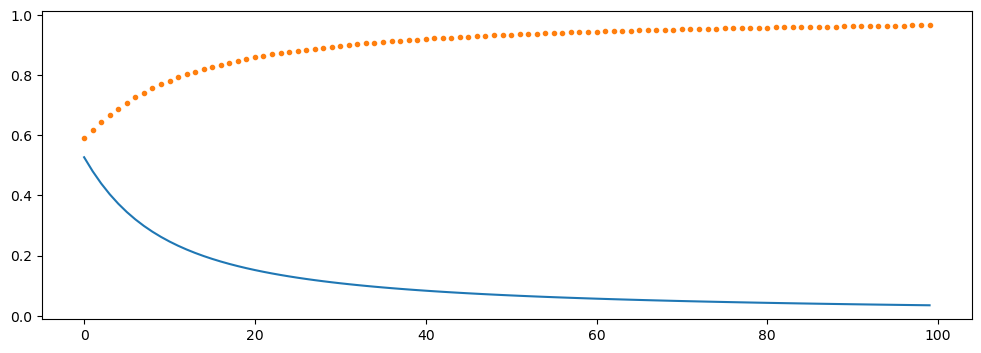

In [13]:
## gradient descent
loss = []
score = []
for i in range(100):
    out = model.predict(x)
    loss.append(model.backward(label=1)) # 1 for positive, 0 for negative
    model.grad_step(lr=1e-1)
    score.append(out)
    
import matplotlib.pyplot as plt
plt.plot(np.array(loss).squeeze(),'-')
plt.plot(np.array(score).squeeze(),'.')

# Summary

* Neural networks are powerful models that can approximate any function.
* They are trained using gradient descent.
* In order to compute gradients, we use an efficient algorithm called backpropagation.